In [ ]:
from src.Data2D import Data2D

## Workflow:

# 1. Instantiate an area/volume class
vis_2d = Data2D()
#segments = vis_2d.import_json('../lines_test.json')
#segments = vis_2d.import_rhino('../rhino_test.3dm')
#segments = vis_2d.import_csv('../lines_hospital.csv',start_xy=('x1','y1'),end_xy=('x2','y2'))
#vis_2d.import_svg('../lines_hospital.svg',pagewidth=20,curve_step=0.2)
#vis_2d.import_pdf('../lines_hospital.pdf',page=1,pagewidth=20,curve_step=0.2,crop_extents=[0,0.8,0,1])
vis_2d.import_image('../lines_hospital.pdf',page=1,pagewidth=20,curve_step=0.2,crop_extents=[0,0.8,0,1])
#vis_2d.view_plan()
#vis_2d.import_array(segments)
#print(vis_2d)

In [2]:
import matplotlib.pyplot as plt

#grid, valid = identify_noninf(vis_2d['plan'],res=0.5)
#vis_2d.view_plan(dark=False)
vis_2d.detect_boundaries(return_dense=False)
#vis_2d.view_areas(dark=False)

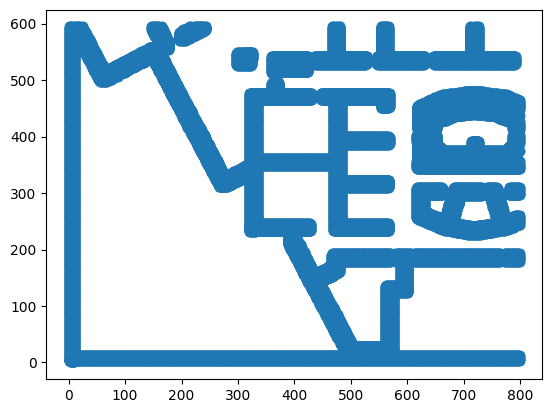

In [33]:
import matplotlib.pyplot as plt
from io_src.import_image import import_img
import numpy as np

img = import_img('../lines_hospital.png',20,crop_extents=[0,0.8,0,0.8])
mask = img>0.7
img[mask] = 0
#edges_pts = np.argwhere(np.nonzero(img))
edges_pts = np.argwhere(img)
plt.scatter(edges_pts[:,1],edges_pts[:,0])
#plt.imshow(img)
#plt.colorbar()

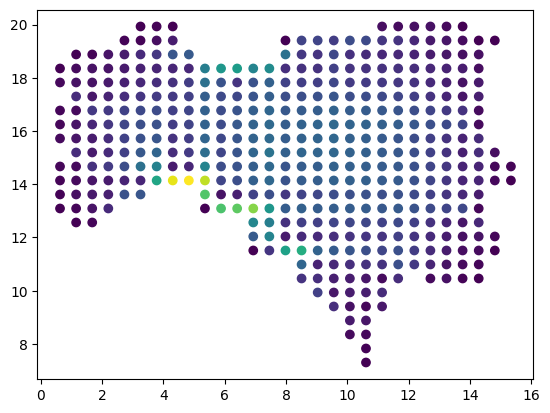

In [7]:
from src.graph_2d import knn_graph, centrality, closeness
import numpy as np
import heapq
import matplotlib.pyplot as plt
grid = vis_2d.results['grid_bounds']
edges = knn_graph(grid)

closeness(grid,edges,weighted=True)
degree = centrality(grid,edges,metric='betweenness_w')
plt.scatter(grid[:,0],grid[:,1],c=degree)

In [ ]:
from src.graph_2d import knn_graph
import numpy as np
grid = vis_2d.results['grid_bounds']
edges = knn_graph(grid)

# get the upper triangle
edges_d = np.unique(np.sort(edges,axis=1),axis=0) #directional edges
edge_weights = np.linalg.norm(grid[edges_d[:,1]] - grid[edges_d[:,0]],axis=1)
dists_init = np.full((grid.shape[0],grid.shape[0]),np.inf)
dists_init[np.diag_indices(grid.shape[0])] = 0
dists_init[edges_d[:,0],edges_d[:,1]] = edge_weights #neighbor weights

known = np.isfinite(dists_init)
node = 0

0
deque([1, 2, 3, 5]) {0: None, 1: 0, 2: 0, 3: 0, 5: 0}
1
deque([2, 3, 5]) {0: None, 1: 0, 2: 0, 3: 0, 5: 0}
2
deque([3, 5, 4]) {0: None, 1: 0, 2: 0, 3: 0, 5: 0, 4: 2}
3
deque([5, 4]) {0: None, 1: 0, 2: 0, 3: 0, 5: 0, 4: 2}
5
deque([4, 7, 8, 9]) {0: None, 1: 0, 2: 0, 3: 0, 5: 0, 4: 2, 7: 5, 8: 5, 9: 5}
4
deque([7, 8, 9, 6]) {0: None, 1: 0, 2: 0, 3: 0, 5: 0, 4: 2, 7: 5, 8: 5, 9: 5, 6: 4}
7
deque([8, 9, 6, 12]) {0: None, 1: 0, 2: 0, 3: 0, 5: 0, 4: 2, 7: 5, 8: 5, 9: 5, 6: 4, 12: 7}
8
deque([9, 6, 12, 13]) {0: None, 1: 0, 2: 0, 3: 0, 5: 0, 4: 2, 7: 5, 8: 5, 9: 5, 6: 4, 12: 7, 13: 8}
9
deque([6, 12, 13, 14]) {0: None, 1: 0, 2: 0, 3: 0, 5: 0, 4: 2, 7: 5, 8: 5, 9: 5, 6: 4, 12: 7, 13: 8, 14: 9}
6
deque([12, 13, 14, 10, 11]) {0: None, 1: 0, 2: 0, 3: 0, 5: 0, 4: 2, 7: 5, 8: 5, 9: 5, 6: 4, 12: 7, 13: 8, 14: 9, 10: 6, 11: 6}
12
deque([13, 14, 10, 11, 18]) {0: None, 1: 0, 2: 0, 3: 0, 5: 0, 4: 2, 7: 5, 8: 5, 9: 5, 6: 4, 12: 7, 13: 8, 14: 9, 10: 6, 11: 6, 18: 12}
13
deque([14, 10, 11, 18, 19]) {0: No

In [ ]:

#vis_2d.dense_calc()

grid = vis_2d.results['area']
#print(grid)
plt.figure()
plt.axis('equal')
for line in vis_2d['plan']:
    plt.plot(line[:,0],line[:,1])
plt.scatter(grid['X'],grid['Y'],c=grid['result'])
#plt.scatter(vis_2d.results['grid_bounds'][:,0],vis_2d.results['grid_bounds'][:,1])
plt.colorbar()
plt.figure()
